Loading SMD-3-1_test_x.npy and SMD-3-1_test_y.npy
[0. 0. 0. ... 0. 0. 0.]
Loaded (28700,) and (28700,)


/tmp/ipykernel_2767891/1175475308.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'SMD-{idx} (Channel: #{chnl_idx+1})', loc='upper left', fontsize=fz)
/tmp/ipykernel_2767891/1175475308.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=model, loc='upper left', fontsize=fz)


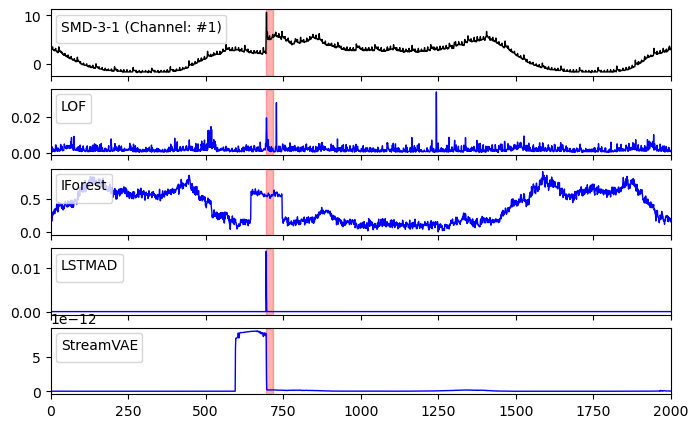

AttributeError: 'NoneType' object has no attribute 'to_latex'

In [ ]:
model_list = ['LOF','IForest','LSTMAD','StreamVAE']#,'LSTMAD', 'USAD', 'AnomalyTransformer']
import sys
pth = r'/home/zzj/projects/CCE/logs/RealWorldAD'
import numpy as np
import pandas as pd
import os

sys.path.append('/home/zzj/projects/CCE/')
from src.metrics.basic_metrics import basic_metricor,convert_vector_to_events
metric_list_ = ['CCE', 'AUC-ROC', 'F1', 'eTaPR', 'UAff-F1', 'VUS-ROC']#,'PATE']

def plot_SMD(idx, cal_metric=False):
    if idx=='3-1':
        # show_range = (0, 28700)
        show_range = (10000, 12000)
    elif idx =='2-1':
        show_range = (15000, 23694)
    elif idx =='1-1':
        show_range = (10000, 28479)
    

    # print(f'Anomaly range: {anom_range}, show range: {show_range}')
    

    chnl_idx = 0
    linewidth = 1 
    fz=8
    quantile = 0.98

    test_x = f'SMD-{idx}_test_x.npy'
    test_y = f'SMD-{idx}_test_y.npy'
    print(f'Loading {test_x} and {test_y}')
    import numpy as np
    test_x = np.load(f'{pth}/{test_x}')
    test_y = np.load(f'{pth}/{test_y}')
    print(test_y)
    anom_ranges = convert_vector_to_events(test_y)
    test_x = test_x[:,chnl_idx]
    print(f'Loaded {test_x.shape} and {test_y.shape}')

    import matplotlib.pyplot as plt

    N_plot = len(model_list)+1

    plt.subplots(N_plot, 1, figsize=(8, 1*N_plot), sharex=True)
    bm = basic_metricor()
    plt.subplot(N_plot, 1, 1)
    plt.plot(test_x[show_range[0]:show_range[1]+1], color='black', linewidth=linewidth)
    # plt.legend(title='Data', loc='upper left', fontsize=fz)
    plt.legend(title=f'SMD-{idx} (Channel: #{chnl_idx+1})', loc='upper left', fontsize=fz)
    # 加一个文字框
    results = {}
    # plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)
    for anom_range in anom_ranges:
        plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)#, label='Anomaly Range')
    for i, model in enumerate(model_list):
        pred = np.load(f'{pth}/SMD-{idx}_{model}_score.npy')
        thresh = np.percentile(pred, quantile*100)
        if model == 'AnomalyTransformer':
            model = 'A.T.'
        plt.subplot(N_plot, 1, i+2)
        # minmax
        min_, max_ = np.min(pred), np.max(pred)
        pred = (pred - np.min(pred)) / (np.max(pred) - np.min(pred))
        thresh = (thresh - min_) / (max_ - min_)
        plt.plot(pred[show_range[0]:show_range[1]+1], color='blue', linewidth=linewidth)
        for anom_range in anom_ranges:
            plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)#, label='Anomaly Range')
        plt.legend(title=model, loc='upper left', fontsize=fz)
        # plt.xticks(np.arange(0,show_range[1]-show_range[0]+1,500),np.arange(show_range[0], show_range[1]+1, 500), rotation=0)
        plt.xlim(0, show_range[1] - show_range[0])
        # 计算指标
        if cal_metric:
            tmp_y = test_y.copy()[show_range[0]:show_range[1]+1]
            print(len(tmp_y))
            tmp_score = pred.copy()[show_range[0]:show_range[1]+1]
            thresh = np.percentile(tmp_score, quantile*100)
            tmp_pred = (tmp_score > thresh).astype(int)
            res = {}
            for mt in metric_list_:
                val = bm.metric_by_name(mt, tmp_y, tmp_score, tmp_pred)
                res[mt] = val
            results[model] = res
    
    # 打印结果
    if cal_metric:
        results = pd.DataFrame(results).T
        results *= 100
        results.to_latex()
        print(results)
    else:
        results = None
    out_pth = r'/home/zzj/projects/CCE/logs/RealWorldAD/SMD'
    if not os.path.exists(out_pth):
        os.mkdir(out_pth)
    plt.savefig(f'{out_pth}/SMD-{idx}.jpg', bbox_inches='tight', dpi=400)
    plt.show()
    return results

pth2 = '/home/zzj/projects/CCE/logs/26-8-7'
# ucr_idx = '3-1'
# results = plot_SMD(ucr_idx, 1)
# latex_str = results.to_latex(float_format="%.2f")
# name = f"{pth2}/SMD-{ucr_idx}.txt"
# with open(name, 'w') as f:
#     f.write(latex_str)
#     f.close()
ucr_idx = '2-1'
results = plot_SMD(ucr_idx, 0)
latex_str = results.to_latex(float_format="%.2f")
name = f"{pth2}/SMD-{ucr_idx}.txt"
with open(name, 'w') as f:
    f.write(latex_str)
    f.close()


Loading NIPS_TS_Creditcard_test_x.npy and NIPS_TS_Creditcard_test_y.npy
[0. 0. 0. ... 0. 0. 0.]
Loaded (284807,) and (284807,)


/tmp/ipykernel_2339240/3917403038.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'{data_name} (Channel: #{chnl_idx+1})', loc='upper left', fontsize=fz)
/tmp/ipykernel_2339240/3917403038.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=model, loc='upper left', fontsize=fz)


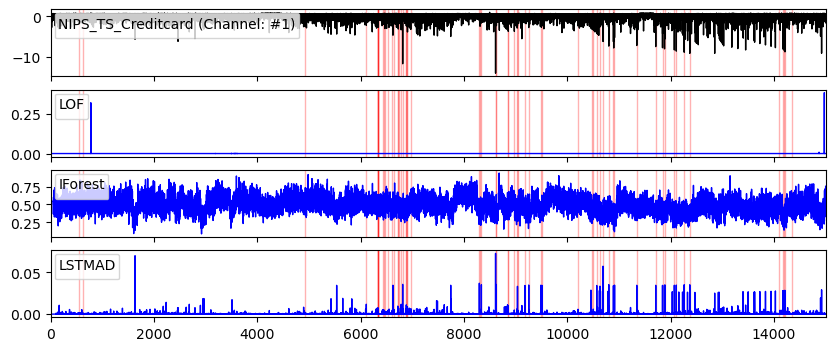

In [9]:

def plot_others(data_name='PSM',cal_metric=False):
    if data_name == 'PSM':
        show_range = (6000, 29000)
    elif data_name == 'SWAT':
        show_range = (0, 15000)
    elif data_name == 'NIPS_TS_Creditcard':
        show_range = (0, 15000)
    

    # print(f'Anomaly range: {anom_range}, show range: {show_range}')
    

    chnl_idx = 0
    linewidth = 1 
    fz=6
    quantile = 0.98

    test_x = f'{data_name}_test_x.npy'
    test_y = f'{data_name}_test_y.npy'
    print(f'Loading {test_x} and {test_y}')
    import numpy as np
    test_x = np.load(f'{pth}/{test_x}')
    test_y = np.load(f'{pth}/{test_y}')
    print(test_y)
    anom_ranges = convert_vector_to_events(test_y)
    test_x = test_x[:,chnl_idx]
    print(f'Loaded {test_x.shape} and {test_y.shape}')

    import matplotlib.pyplot as plt

    N_plot = len(model_list)+1

    plt.subplots(N_plot, 1, figsize=(10, 1*N_plot), sharex=True)
    bm = basic_metricor()
    plt.subplot(N_plot, 1, 1)
    plt.plot(test_x[show_range[0]:show_range[1]+1], color='black', linewidth=linewidth)
    plt.legend(title=f'{data_name} (Channel: #{chnl_idx+1})', loc='upper left', fontsize=fz)
    # 加一个文字框
    results = {}
    # plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)
    for anom_range in anom_ranges:
        plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)#, label='Anomaly Range')
    for i, model in enumerate(model_list):
        pred = np.load(f'{pth}/{data_name}_{model}_score.npy')
        thresh = np.percentile(pred, quantile*100)
        if model == 'AnomalyTransformer':
            model = 'A.T.'
        plt.subplot(N_plot, 1, i+2)
        # minmax
        min_, max_ = np.min(pred), np.max(pred)
        pred = (pred - np.min(pred)) / (np.max(pred) - np.min(pred))
        thresh = (thresh - min_) / (max_ - min_)
        plt.plot(pred[show_range[0]:show_range[1]+1], color='blue', linewidth=linewidth)
        for anom_range in anom_ranges:
            plt.axvspan(anom_range[0]-show_range[0], anom_range[1]-show_range[0], color='red', alpha=0.3)#, label='Anomaly Range')
        plt.legend(title=model, loc='upper left', fontsize=fz)
        # plt.xticks(np.arange(0,show_range[1]-show_range[0]+1,500),np.arange(show_range[0], show_range[1]+1, 500), rotation=0)
        plt.xlim(0, show_range[1] - show_range[0])
        # 计算指标
        if cal_metric:
            tmp_y = test_y.copy()[show_range[0]:show_range[1]+1]
            print(len(tmp_y))
            tmp_score = pred.copy()[show_range[0]:show_range[1]+1]
            thresh = np.percentile(tmp_score, quantile*100)
            tmp_pred = (tmp_score > thresh).astype(int)
            res = {}
            for mt in metric_list_:
                val = bm.metric_by_name(mt, tmp_y, tmp_score, tmp_pred)
                res[mt] = val
            results[model] = res
    
    # 打印结果
    if cal_metric:
        results = pd.DataFrame(results).T
        results *= 100
        results.to_latex()
        print(results)
    else:
        results = None
    out_pth = r'/home/zzj/projects/CCE/logs/RealWorldAD/SMD'
    if not os.path.exists(out_pth):
        os.mkdir(out_pth)
    plt.savefig(f'{out_pth}/{data_name}.jpg', bbox_inches='tight', dpi=400)
    plt.show()
    return results
data_name = 'SWAT'
data_name = 'NIPS_TS_Creditcard'
model_list = ['LOF','IForest','LSTMAD']#,'StreamVAE']
results = plot_others(data_name, 0)
results

In [ ]:


# latex_str = results.to_latex(float_format="%.2f")
# pth = '/home/zzj/projects/CCE/logs/26-8-7'


# name = f"{pth}/UCR-{ucr_idx}.txt"
# with open(name, 'w') as f:
#     f.write(latex_str)
#     f.close()
    

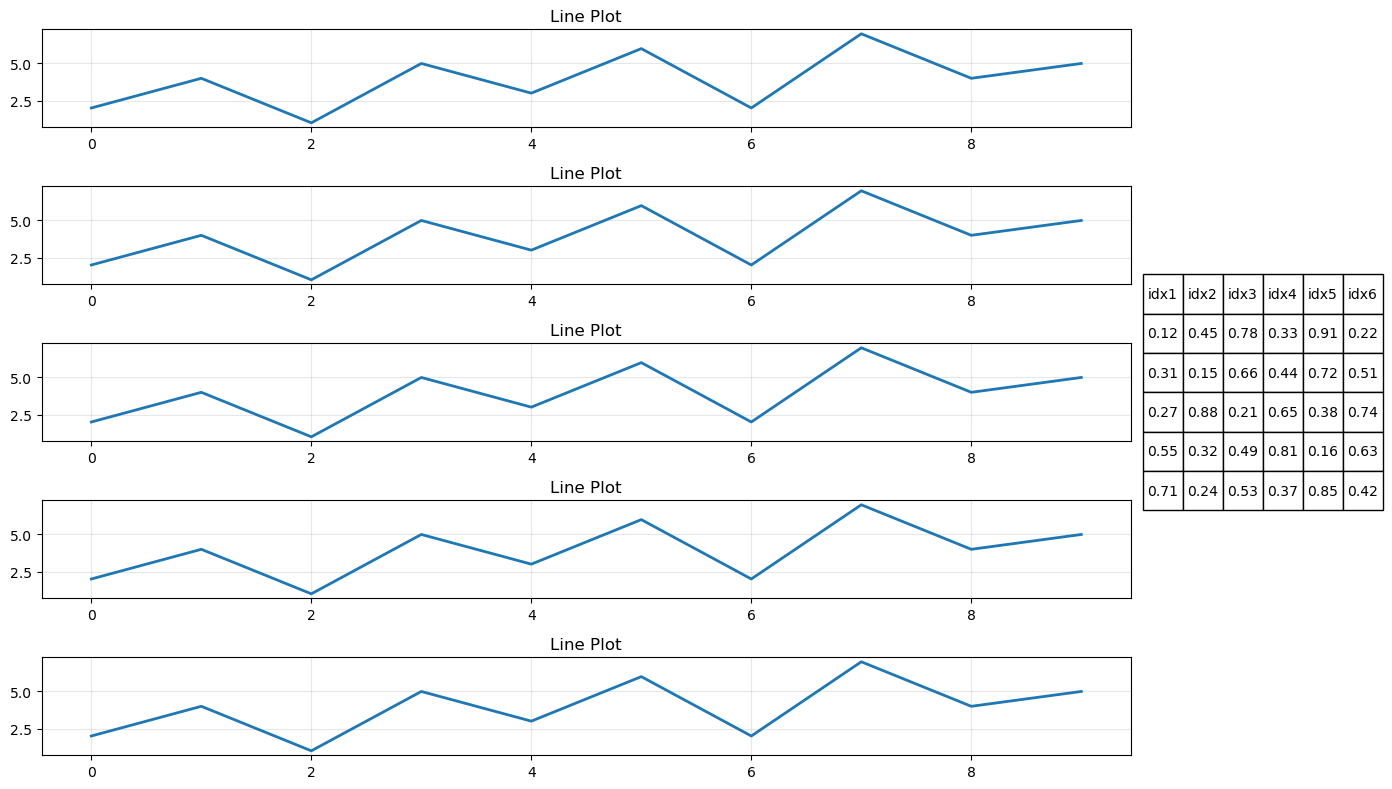

In [38]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

fig = plt.figure(figsize=(14, 8))
# 总网格：5行，一共7列：第0列给图，1‑6共6列给表格
gs = gridspec.GridSpec(nrows=5, ncols=2, width_ratios=[10] + [2])

for i in range(5):
    # 左边：跨全部5行，第0列，绘制线条
    ax_plot = fig.add_subplot(gs[i, 0])
    x = list(range(10))
    y = [2,4,1,5,3,6,2,7,4,5]
    ax_plot.plot(x, y, color="#1f77b4", linewidth=2)
    ax_plot.set_title("Line Plot")
    ax_plot.grid(True, alpha=0.3)


# 右边：5行6列的表格，放在 gs[0:5, 1:7]
ax_table = fig.add_subplot(gs[0:5, 1])
ax_table.axis("off")
ax_table.axis("tight")

# 5行数据，6列指标
table_data = [
    [0.12, 0.45, 0.78, 0.33, 0.91, 0.22],
    [0.31, 0.15, 0.66, 0.44, 0.72, 0.51],
    [0.27, 0.88, 0.21, 0.65, 0.38, 0.74],
    [0.55, 0.32, 0.49, 0.81, 0.16, 0.63],
    [0.71, 0.24, 0.53, 0.37, 0.85, 0.42],
]
col_labels = ["idx1", "idx2", "idx3", "idx4", "idx5", "idx6"]

tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
# 调整单元格宽高
tbl.scale(1.1, 2.0)

plt.tight_layout()
plt.show()